# Resource & Utilization Analysis

In [1]:
# RESOURCE & UTILIZATION ANALYSIS
# Using Python, MySQL and Pandas

# 2. Import Libraries and Connect Python to MySQL

In [1]:
import mysql.connector
import pandas as pd
import random

from datetime import date, timedelta

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root"
)

cursor = conn.cursor()

print("MySQL Connected Successfully")

MySQL Connected Successfully


# 3. Create Database

In [2]:
cursor.execute("""
CREATE DATABASE IF NOT EXISTS resource_utilization
""")

cursor.execute("""
USE resource_utilization
""")

print("Database selected successfully")

Database selected successfully


# 4. Create Departments Table

In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS departments(
    department_id INT AUTO_INCREMENT PRIMARY KEY,
    department_name VARCHAR(100) NOT NULL
)
""")

conn.commit()

# 5. Create Employees Table

In [4]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees(
    employee_id INT AUTO_INCREMENT PRIMARY KEY,
    employee_name VARCHAR(100),
    department_id INT,
    designation VARCHAR(100),
    experience_years INT,
    FOREIGN KEY (department_id)
        REFERENCES departments(department_id)
)
""")

conn.commit()

# 6. Create Projects Table

In [5]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS projects(
    project_id INT AUTO_INCREMENT PRIMARY KEY,
    project_name VARCHAR(100),
    department_id INT,
    start_date DATE,
    end_date DATE,
    project_budget DECIMAL(12,2),
    FOREIGN KEY (department_id)
        REFERENCES departments(department_id)
)
""")

conn.commit()

# 7. Create Resource Allocation Table

In [6]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS resource_allocation(
    allocation_id INT AUTO_INCREMENT PRIMARY KEY,
    employee_id INT,
    project_id INT,
    allocation_date DATE,
    allocated_hours INT,
    FOREIGN KEY (employee_id)
        REFERENCES employees(employee_id),
    FOREIGN KEY (project_id)
        REFERENCES projects(project_id)
)
""")

conn.commit()

# 8. Create Timesheet Table

In [7]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS timesheet(
    timesheet_id INT AUTO_INCREMENT PRIMARY KEY,
    employee_id INT,
    project_id INT,
    work_date DATE,
    actual_hours INT,
    FOREIGN KEY (employee_id)
        REFERENCES employees(employee_id),
    FOREIGN KEY (project_id)
        REFERENCES projects(project_id)
)
""")

conn.commit()

# 9. Insert Departments

In [8]:
departments = [
    ("Data Analytics",),
    ("Software Development",),
    ("Human Resources",),
    ("Finance",),
    ("Marketing",)
]

cursor.executemany("""
INSERT INTO departments(department_name)
VALUES (%s)
""", departments)

conn.commit()

print("Departments inserted")

Departments inserted


# 10. Insert Employees

In [9]:
employees = [
    ("Akash", 1, "Data Analyst", 2),
    ("Rahul", 1, "Senior Data Analyst", 5),
    ("Priya", 1, "Data Scientist", 3),
    ("Sneha", 1, "Business Analyst", 4),

    ("Amit", 2, "Python Developer", 3),
    ("Neha", 2, "Software Engineer", 2),
    ("Rohit", 2, "Backend Developer", 5),
    ("Pooja", 2, "Frontend Developer", 3),

    ("Kiran", 3, "HR Executive", 2),
    ("Anjali", 3, "HR Manager", 6),
    ("Vikas", 3, "Recruiter", 3),
    ("Meena", 3, "HR Analyst", 2),

    ("Suresh", 4, "Financial Analyst", 4),
    ("Riya", 4, "Accountant", 3),
    ("Nikhil", 4, "Finance Manager", 7),
    ("Komal", 4, "Financial Associate", 2),

    ("Varun", 5, "Marketing Executive", 2),
    ("Ayesha", 5, "Marketing Manager", 6),
    ("Manish", 5, "SEO Specialist", 3),
    ("Divya", 5, "Marketing Analyst", 2)
]

cursor.executemany("""
INSERT INTO employees
(employee_name, department_id, designation, experience_years)
VALUES (%s, %s, %s, %s)
""", employees)

conn.commit()

print("Employees inserted")

Employees inserted


# 11. Insert Projects

In [10]:
projects = [
    ("Sales Analytics Dashboard", 1, date(2024,1,10), date(2024,4,30), 500000),
    ("Customer Churn Analysis", 1, date(2024,2,1), date(2024,5,30), 350000),
    ("Machine Learning Platform", 2, date(2024,1,15), date(2024,7,30), 900000),
    ("E-Commerce Website", 2, date(2024,3,1), date(2024,8,30), 1200000),
    ("Employee Management System", 3, date(2024,2,15), date(2024,6,30), 400000),
    ("Payroll Automation", 4, date(2024,1,20), date(2024,5,20), 450000),
    ("Digital Marketing Campaign", 5, date(2024,3,10), date(2024,6,10), 300000),
    ("Customer Acquisition Project", 5, date(2024,4,1), date(2024,8,1), 550000)
]

cursor.executemany("""
INSERT INTO projects
(project_name, department_id, start_date, end_date, project_budget)
VALUES (%s, %s, %s, %s, %s)
""", projects)

conn.commit()

print("Projects inserted")

Projects inserted


# 12. Generate Resource Allocation Data

In [11]:
allocation_data = []

start_date = date(2024,1,1)

for _ in range(100):
    
    employee_id = random.randint(1,20)
    project_id = random.randint(1,8)
    
    allocation_date = start_date + timedelta(
        days=random.randint(0,240)
    )
    
    allocated_hours = random.randint(80,180)
    
    allocation_data.append((
        employee_id,
        project_id,
        allocation_date,
        allocated_hours
    ))

cursor.executemany("""
INSERT INTO resource_allocation
(employee_id, project_id, allocation_date, allocated_hours)
VALUES (%s, %s, %s, %s)
""", allocation_data)

conn.commit()

print("Resource allocation data inserted")

Resource allocation data inserted


# 13. Generate Timesheet Data

In [12]:
timesheet_data = []

for _ in range(150):
    
    employee_id = random.randint(1,20)
    project_id = random.randint(1,8)
    
    work_date = start_date + timedelta(
        days=random.randint(0,240)
    )
    
    actual_hours = random.randint(40,190)
    
    timesheet_data.append((
        employee_id,
        project_id,
        work_date,
        actual_hours
    ))

cursor.executemany("""
INSERT INTO timesheet
(employee_id, project_id, work_date, actual_hours)
VALUES (%s, %s, %s, %s)
""", timesheet_data)

conn.commit()

print("Timesheet data inserted")

Timesheet data inserted


# 14. Check Tables

In [13]:
cursor.execute("SHOW TABLES")

for table in cursor.fetchall():
    print(table[0])

departments
employees
projects
resource_allocation
timesheet


# SQL ANALYSIS

# 15. Display All Employees

In [14]:
query = """
SELECT *
FROM employees
"""

df = pd.read_sql(query, conn)

df.head(10)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\2292482063.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_id,employee_name,department_id,designation,experience_years
0,1,Akash,1,Data Analyst,2
1,2,Rahul,1,Senior Data Analyst,5
2,3,Priya,1,Data Scientist,3
3,4,Sneha,1,Business Analyst,4
4,5,Amit,2,Python Developer,3
5,6,Neha,2,Software Engineer,2
6,7,Rohit,2,Backend Developer,5
7,8,Pooja,2,Frontend Developer,3
8,9,Kiran,3,HR Executive,2
9,10,Anjali,3,HR Manager,6


# 16. Display Employees with Department

In [15]:
query = """
SELECT
    e.employee_id,
    e.employee_name,
    d.department_name,
    e.designation,
    e.experience_years
FROM employees e
JOIN departments d
ON e.department_id = d.department_id
"""

employee_df = pd.read_sql(query, conn)

employee_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\834395407.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employee_df = pd.read_sql(query, conn)


,employee_id,employee_name,department_name,designation,experience_years
0,1,Akash,Data Analytics,Data Analyst,2
1,2,Rahul,Data Analytics,Senior Data Analyst,5
2,3,Priya,Data Analytics,Data Scientist,3
3,4,Sneha,Data Analytics,Business Analyst,4
4,5,Amit,Software Development,Python Developer,3
5,6,Neha,Software Development,Software Engineer,2
6,7,Rohit,Software Development,Backend Developer,5
7,8,Pooja,Software Development,Frontend Developer,3
8,9,Kiran,Human Resources,HR Executive,2
9,10,Anjali,Human Resources,HR Manager,6


# 17. Total Allocated Hours

In [16]:
query = """
SELECT
    SUM(allocated_hours) AS total_allocated_hours
FROM resource_allocation
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\3874888992.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,total_allocated_hours
0,13189.0


# 18. Total Actual Hours

In [17]:
query = """
SELECT
    SUM(actual_hours) AS total_actual_hours
FROM timesheet
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\3050858503.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,total_actual_hours
0,17197.0


# 19. Employee-wise Allocated Hours

In [18]:
query = """
SELECT
    e.employee_name,
    SUM(r.allocated_hours) AS total_allocated_hours
FROM employees e
JOIN resource_allocation r
ON e.employee_id = r.employee_id
GROUP BY e.employee_id, e.employee_name
ORDER BY total_allocated_hours DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1747046213.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_name,total_allocated_hours
0,Nikhil,1414.0
1,Pooja,1225.0
2,Riya,1054.0
3,Komal,1043.0
4,Manish,891.0
5,Sneha,890.0
6,Priya,855.0
7,Suresh,779.0
8,Neha,672.0
9,Anjali,594.0


# 20. Employee-wise Actual Hours

In [19]:
query = """
SELECT
    e.employee_name,
    SUM(t.actual_hours) AS total_actual_hours
FROM employees e
JOIN timesheet t
ON e.employee_id = t.employee_id
GROUP BY e.employee_id, e.employee_name
ORDER BY total_actual_hours DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\3366185684.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_name,total_actual_hours
0,Rahul,1327.0
1,Manish,1316.0
2,Neha,1309.0
3,Suresh,1235.0
4,Varun,1184.0
5,Ayesha,1061.0
6,Anjali,1047.0
7,Vikas,959.0
8,Pooja,913.0
9,Priya,890.0


# 22. Find Underutilized Employees

In [20]:
query = """
SELECT
    e.employee_name,
    SUM(r.allocated_hours) AS allocated_hours,
    COALESCE(SUM(t.actual_hours),0) AS actual_hours,

    ROUND(
        COALESCE(SUM(t.actual_hours),0)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

LEFT JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

HAVING utilization_percentage < 60

ORDER BY utilization_percentage
"""

underutilized_df = pd.read_sql(query, conn)

underutilized_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1886704061.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  underutilized_df = pd.read_sql(query, conn)


,employee_name,allocated_hours,actual_hours,utilization_percentage


# 23. Find Overutilized Employees

In [21]:
query = """
SELECT
    e.employee_name,
    SUM(r.allocated_hours) AS allocated_hours,
    COALESCE(SUM(t.actual_hours),0) AS actual_hours,

    ROUND(
        COALESCE(SUM(t.actual_hours),0)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

LEFT JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

HAVING utilization_percentage > 100

ORDER BY utilization_percentage DESC
"""

overutilized_df = pd.read_sql(query, conn)

overutilized_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\2231002151.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  overutilized_df = pd.read_sql(query, conn)


,employee_name,allocated_hours,actual_hours,utilization_percentage
0,Amit,1685.0,2169.0,128.72
1,Neha,7392.0,7854.0,106.25
2,Manish,8910.0,9212.0,103.39


# 24. Employee Utilization Classification

In [22]:
utilization_df["utilization_status"] = utilization_df[
    "utilization_percentage"
].apply(
    lambda x:
        "Underutilized" if x < 60
        else "Optimal" if x <= 90
        else "Highly Utilized" if x <= 100
        else "Overutilized"
)

utilization_df

NameError: name 'utilization_df' is not defined

# 24. Employee Utilization Classification

In [ ]:
utilization_df["utilization_status"] = utilization_df[
    "utilization_percentage"
].apply(
    lambda x:
        "Underutilized" if x < 60
        else "Optimal" if x <= 90
        else "Highly Utilized" if x <= 100
        else "Overutilized"
)

utilization_df

# 25. Department-wise Utilization

In [23]:
query = """
SELECT
    d.department_name,

    SUM(r.allocated_hours) AS allocated_hours,

    SUM(t.actual_hours) AS actual_hours,

    ROUND(
        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM departments d

JOIN employees e
ON d.department_id = e.department_id

JOIN resource_allocation r
ON e.employee_id = r.employee_id

JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    d.department_id,
    d.department_name

ORDER BY utilization_percentage DESC
"""

department_df = pd.read_sql(query, conn)

department_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\2346303457.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  department_df = pd.read_sql(query, conn)


,department_name,allocated_hours,actual_hours,utilization_percentage
0,Software Development,21201.0,19888.0,93.81
1,Marketing,18563.0,17253.0,92.94
2,Finance,26113.0,21761.0,83.33
3,Data Analytics,17806.0,14393.0,80.83
4,Human Resources,12430.0,9731.0,78.29


# 26. Project-wise Resource Utilization

In [24]:
query = """
SELECT
    p.project_name,

    SUM(r.allocated_hours) AS allocated_hours,

    SUM(t.actual_hours) AS actual_hours,

    ROUND(
        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM projects p

JOIN resource_allocation r
ON p.project_id = r.project_id

JOIN timesheet t
ON p.project_id = t.project_id

GROUP BY
    p.project_id,
    p.project_name

ORDER BY utilization_percentage DESC
"""

project_df = pd.read_sql(query, conn)

project_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1480013766.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  project_df = pd.read_sql(query, conn)


,project_name,allocated_hours,actual_hours,utilization_percentage
0,Machine Learning Platform,20574.0,19629.0,95.41
1,Payroll Automation,23596.0,22429.0,95.05
2,Sales Analytics Dashboard,41325.0,37232.0,90.10
3,Employee Management System,23693.0,21141.0,89.23
4,Customer Acquisition Project,26280.0,22816.0,86.82
5,Customer Churn Analysis,37796.0,31430.0,83.16
6,E-Commerce Website,31584.0,24990.0,79.12
7,Digital Marketing Campaign,36839.0,27744.0,75.31


# 27. Highest Utilized Employee

In [25]:
query = """
SELECT
    e.employee_name,

    ROUND(
        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

ORDER BY utilization_percentage DESC

LIMIT 1
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1403118684.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_name,utilization_percentage
0,Amit,128.72


# 28. Lowest Utilized Employee

In [26]:
query = """
SELECT
    p.project_name,

    SUM(r.allocated_hours) AS allocated_hours,

    SUM(t.actual_hours) AS actual_hours,

    ROUND(
        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM projects p

JOIN resource_allocation r
ON p.project_id = r.project_id

JOIN timesheet t
ON p.project_id = t.project_id

GROUP BY
    p.project_id,
    p.project_name

ORDER BY utilization_percentage DESC
"""

project_df = pd.read_sql(query, conn)

project_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1480013766.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  project_df = pd.read_sql(query, conn)


,project_name,allocated_hours,actual_hours,utilization_percentage
0,Machine Learning Platform,20574.0,19629.0,95.41
1,Payroll Automation,23596.0,22429.0,95.05
2,Sales Analytics Dashboard,41325.0,37232.0,90.10
3,Employee Management System,23693.0,21141.0,89.23
4,Customer Acquisition Project,26280.0,22816.0,86.82
5,Customer Churn Analysis,37796.0,31430.0,83.16
6,E-Commerce Website,31584.0,24990.0,79.12
7,Digital Marketing Campaign,36839.0,27744.0,75.31


# 29. Employees Working on Multiple Projects

In [27]:
query = """
SELECT
    e.employee_name,
    COUNT(DISTINCT r.project_id) AS project_count

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

HAVING project_count > 1

ORDER BY project_count DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1644526482.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_name,project_count
0,Riya,7
1,Pooja,6
2,Sneha,5
3,Nikhil,5
4,Komal,5
5,Manish,5
6,Priya,4
7,Neha,4
8,Rohit,4
9,Vikas,4


# 30. Project Budget Analysis

In [28]:
query = """
SELECT
    project_name,
    project_budget
FROM projects
ORDER BY project_budget DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\958267611.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,project_name,project_budget
0,E-Commerce Website,1200000.0
1,Machine Learning Platform,900000.0
2,Customer Acquisition Project,550000.0
3,Sales Analytics Dashboard,500000.0
4,Payroll Automation,450000.0
5,Employee Management System,400000.0
6,Customer Churn Analysis,350000.0
7,Digital Marketing Campaign,300000.0


# 31. Total Budget by Department

In [29]:
query = """
SELECT
    d.department_name,
    SUM(p.project_budget) AS total_budget

FROM departments d

JOIN projects p
ON d.department_id = p.department_id

GROUP BY
    d.department_id,
    d.department_name

ORDER BY total_budget DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\4290939152.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,department_name,total_budget
0,Software Development,2100000.0
1,Data Analytics,850000.0
2,Marketing,850000.0
3,Finance,450000.0
4,Human Resources,400000.0


# 32. Resource Gap Analysis

In [30]:
query = """
SELECT
    e.employee_name,

    SUM(r.allocated_hours) AS allocated_hours,

    SUM(t.actual_hours) AS actual_hours,

    SUM(t.actual_hours) - SUM(r.allocated_hours)
    AS resource_gap

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

ORDER BY resource_gap DESC
"""

gap_df = pd.read_sql(query, conn)

gap_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\3366419008.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gap_df = pd.read_sql(query, conn)


,employee_name,allocated_hours,actual_hours,resource_gap
0,Amit,1685.0,2169.0,484.0
1,Neha,7392.0,7854.0,462.0
2,Manish,8910.0,9212.0,302.0
3,Riya,4216.0,4184.0,-32.0
4,Meena,1864.0,1707.0,-157.0
5,Varun,1370.0,1184.0,-186.0
6,Vikas,4032.0,3836.0,-196.0
7,Rahul,4560.0,3981.0,-579.0
8,Divya,3216.0,2613.0,-603.0
9,Sneha,4450.0,3784.0,-666.0


# 33. Employees with Resource Shortage

In [31]:
query = """
SELECT
    e.employee_name,

    SUM(r.allocated_hours) AS allocated_hours,

    SUM(t.actual_hours) AS actual_hours,

    SUM(t.actual_hours) - SUM(r.allocated_hours)
    AS additional_hours_required

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

HAVING additional_hours_required > 0

ORDER BY additional_hours_required DESC
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\4151271045.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,employee_name,allocated_hours,actual_hours,additional_hours_required
0,Amit,1685.0,2169.0,484.0
1,Neha,7392.0,7854.0,462.0
2,Manish,8910.0,9212.0,302.0


# 34. Average Employee Utilization

In [32]:
query = """
SELECT
    ROUND(
        AVG(utilization_percentage),
        2
    ) AS average_utilization

FROM
(
    SELECT
        e.employee_id,

        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100
        AS utilization_percentage

    FROM employees e

    JOIN resource_allocation r
    ON e.employee_id = r.employee_id

    JOIN timesheet t
    ON e.employee_id = t.employee_id

    GROUP BY e.employee_id
) AS utilization_data
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1175402782.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,average_utilization
0,86.77


# 35. Top 5 Employees by Utilization

In [33]:
query = """
SELECT
    e.employee_name,

    ROUND(
        SUM(t.actual_hours)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM employees e

JOIN resource_allocation r
ON e.employee_id = r.employee_id

JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name

ORDER BY utilization_percentage DESC

LIMIT 5
"""

top5_df = pd.read_sql(query, conn)

top5_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1592789742.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top5_df = pd.read_sql(query, conn)


,employee_name,utilization_percentage
0,Amit,128.72
1,Neha,106.25
2,Manish,103.39
3,Riya,99.24
4,Vikas,95.14


# 36. Top 3 Projects by Resource Usage

In [34]:
query = """
SELECT
    p.project_name,
    SUM(t.actual_hours) AS total_actual_hours

FROM projects p

JOIN timesheet t
ON p.project_id = t.project_id

GROUP BY
    p.project_id,
    p.project_name

ORDER BY total_actual_hours DESC

LIMIT 3
"""

df = pd.read_sql(query, conn)

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\3320490990.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,project_name,total_actual_hours
0,Customer Acquisition Project,2852.0
1,Employee Management System,2349.0
2,Sales Analytics Dashboard,2327.0


# 37. Visualization Using Matplotlib

In [35]:
import matplotlib.pyplot as plt

In [36]:
# Employee Utilization

plt.figure(figsize=(12,6))

plt.bar(
    utilization_df["employee_name"],
    utilization_df["utilization_percentage"]
)

plt.axhline(
    100,
    linestyle="--",
    label="100% Utilization"
)

plt.xticks(rotation=45)

plt.xlabel("Employee")
plt.ylabel("Utilization Percentage")

plt.title("Employee Resource Utilization")

plt.legend()

plt.tight_layout()

plt.show()

NameError: name 'utilization_df' is not defined

<Figure size 1200x600 with 0 Axes>

# 38. Department Utilization Chart

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    department_df["department_name"],
    department_df["utilization_percentage"]
)

plt.xlabel("Department")

plt.ylabel("Utilization %")

plt.title("Department-wise Resource Utilization")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

# 39. Project Utilization Chart

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    project_df["project_name"],
    project_df["utilization_percentage"]
)

plt.xlabel("Project")

plt.ylabel("Utilization %")

plt.title("Project-wise Resource Utilization")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 40. Actual vs Allocated Hours

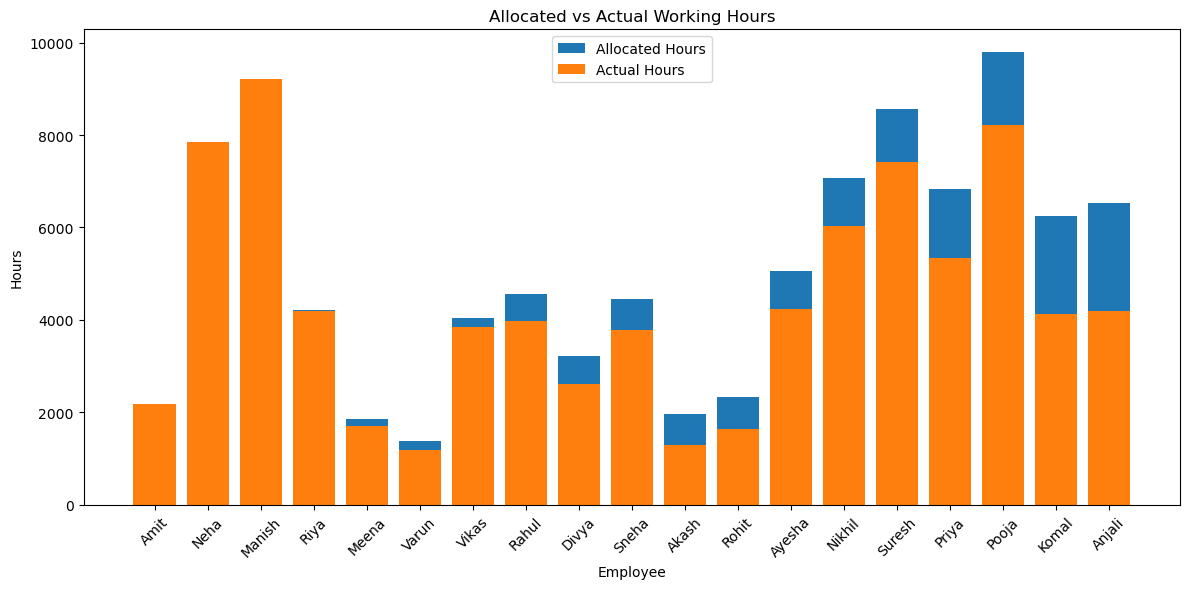

In [37]:
plt.figure(figsize=(12,6))

x = range(len(gap_df))

plt.bar(
    x,
    gap_df["allocated_hours"],
    label="Allocated Hours"
)

plt.bar(
    x,
    gap_df["actual_hours"],
    bottom=gap_df["allocated_hours"] * 0,
    label="Actual Hours"
)

plt.xticks(
    x,
    gap_df["employee_name"],
    rotation=45
)

plt.xlabel("Employee")

plt.ylabel("Hours")

plt.title("Allocated vs Actual Working Hours")

plt.legend()

plt.tight_layout()

plt.show()

# 41. Final Resource Utilization Report

In [38]:
query = """
SELECT
    e.employee_id,
    e.employee_name,
    d.department_name,
    e.designation,

    SUM(r.allocated_hours) AS allocated_hours,

    COALESCE(SUM(t.actual_hours),0) AS actual_hours,

    ROUND(
        COALESCE(SUM(t.actual_hours),0)
        / SUM(r.allocated_hours) * 100,
        2
    ) AS utilization_percentage

FROM employees e

JOIN departments d
ON e.department_id = d.department_id

JOIN resource_allocation r
ON e.employee_id = r.employee_id

LEFT JOIN timesheet t
ON e.employee_id = t.employee_id

GROUP BY
    e.employee_id,
    e.employee_name,
    d.department_name,
    e.designation

ORDER BY utilization_percentage DESC
"""

final_report = pd.read_sql(query, conn)

final_report

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3916\1722735740.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  final_report = pd.read_sql(query, conn)


,employee_id,employee_name,department_name,designation,allocated_hours,actual_hours,utilization_percentage
0,5,Amit,Software Development,Python Developer,1685.0,2169.0,128.72
1,6,Neha,Software Development,Software Engineer,7392.0,7854.0,106.25
2,19,Manish,Marketing,SEO Specialist,8910.0,9212.0,103.39
3,14,Riya,Finance,Accountant,4216.0,4184.0,99.24
4,11,Vikas,Human Resources,Recruiter,4032.0,3836.0,95.14
5,12,Meena,Human Resources,HR Analyst,1864.0,1707.0,91.58
6,2,Rahul,Data Analytics,Senior Data Analyst,4560.0,3981.0,87.30
7,13,Suresh,Finance,Financial Analyst,8569.0,7410.0,86.47
8,17,Varun,Marketing,Marketing Executive,1370.0,1184.0,86.42
9,15,Nikhil,Finance,Finance Manager,7070.0,6039.0,85.42


# 42. Add Utilization Status

In [39]:
def utilization_status(value):

    if value < 60:
        return "Underutilized"

    elif value <= 90:
        return "Optimal"

    elif value <= 100:
        return "Highly Utilized"

    else:
        return "Overutilized"


final_report["utilization_status"] = (
    final_report["utilization_percentage"]
    .apply(utilization_status)
)

final_report

,employee_id,employee_name,department_name,designation,allocated_hours,actual_hours,utilization_percentage,utilization_status
0,5,Amit,Software Development,Python Developer,1685.0,2169.0,128.72,Overutilized
1,6,Neha,Software Development,Software Engineer,7392.0,7854.0,106.25,Overutilized
2,19,Manish,Marketing,SEO Specialist,8910.0,9212.0,103.39,Overutilized
3,14,Riya,Finance,Accountant,4216.0,4184.0,99.24,Highly Utilized
4,11,Vikas,Human Resources,Recruiter,4032.0,3836.0,95.14,Highly Utilized
5,12,Meena,Human Resources,HR Analyst,1864.0,1707.0,91.58,Highly Utilized
6,2,Rahul,Data Analytics,Senior Data Analyst,4560.0,3981.0,87.30,Optimal
7,13,Suresh,Finance,Financial Analyst,8569.0,7410.0,86.47,Optimal
8,17,Varun,Marketing,Marketing Executive,1370.0,1184.0,86.42,Optimal
9,15,Nikhil,Finance,Finance Manager,7070.0,6039.0,85.42,Optimal


# 43. Export Final Report to CSV

In [40]:
final_report.to_csv(
    "resource_utilization_report.csv",
    index=False
)

print("Report generated successfully")

Report generated successfully


# 44. Close Connection

In [41]:
cursor.close()
conn.close()

print("MySQL connection closed")

MySQL connection closed
